# Mercari Price Suggestion Challenge — EDA
## Adım 2: Keşifsel Veri Analizi

Bu notebook'ta veriyi derinlemesine inceleyeceğiz:
1. **Genel bakış** — boyut, tipler, ilk satırlar
2. **Eksik veri analizi** — brand_name, category_name, item_description
3. **Hedef değişken (price)** — dağılım, log dönüşümü, outlier'lar
4. **Kategorik değişkenler** — kategori hiyerarşisi, marka dağılımı, condition, shipping
5. **Metin analizi** — açıklama uzunlukları, kelime frekansları
6. **Değişkenler arası ilişkiler** — fiyata etki eden faktörler
7. **Sonuç ve öneriler** — feature engineering için çıkarımlar


In [4]:
import os
# Mevcut dizini kontrol et
print("Şu anki dizin:", os.getcwd())

# Proje kök dizinine git
os.chdir('/home/cevdetkopuz/mercari-price-prediction')
print("Yeni dizin:", os.getcwd())

# train.tsv var mı kontrol et
print("train.tsv mevcut:", os.path.exists('data/raw/train.tsv'))

Şu anki dizin: /home/cevdetkopuz/mercari-price-prediction/notebooks
Yeni dizin: /home/cevdetkopuz/mercari-price-prediction
train.tsv mevcut: True


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

print("Kütüphaneler yüklendi!")


Kütüphaneler yüklendi!


## 1. Genel Bakış

In [6]:
# Veriyi yükle
df = pd.read_csv('data/raw/train.tsv', sep='\t')

print(f"Veri seti boyutu: {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"Bellek kullanımı: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
df.head()


Veri seti boyutu: 1,482,535 satır × 8 sütun
Bellek kullanımı: 668.6 MB



,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [7]:
# Veri tipleri ve null olmayan değer sayıları
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [8]:
# Sayısal sütunların istatistikleri
df.describe()


,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


## 2. Eksik Veri Analizi

In [9]:
# Eksik veri tablosu
missing = pd.DataFrame({
    'Eksik Sayı': df.isnull().sum(),
    'Eksik Oran (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Eksik Sayı'] > 0].sort_values('Eksik Oran (%)', ascending=False)
print("=== Eksik Veriler ===")
print(missing)
print()

# "No description yet" olanları da kontrol et
no_desc = (df['item_description'] == 'No description yet').sum()
print(f'"No description yet" olan satır sayısı: {no_desc:,} ({no_desc/len(df)*100:.2f}%)')
print()

# Fiyatı 0 olan ürünler
zero_price = (df['price'] == 0).sum()
print(f'Fiyatı $0 olan ürün sayısı: {zero_price:,} ({zero_price/len(df)*100:.2f}%)')


=== Eksik Veriler ===
                  Eksik Sayı  Eksik Oran (%)
brand_name            632682           42.68
category_name           6327            0.43
item_description           6            0.00

"No description yet" olan satır sayısı: 82,489 (5.56%)

Fiyatı $0 olan ürün sayısı: 874 (0.06%)


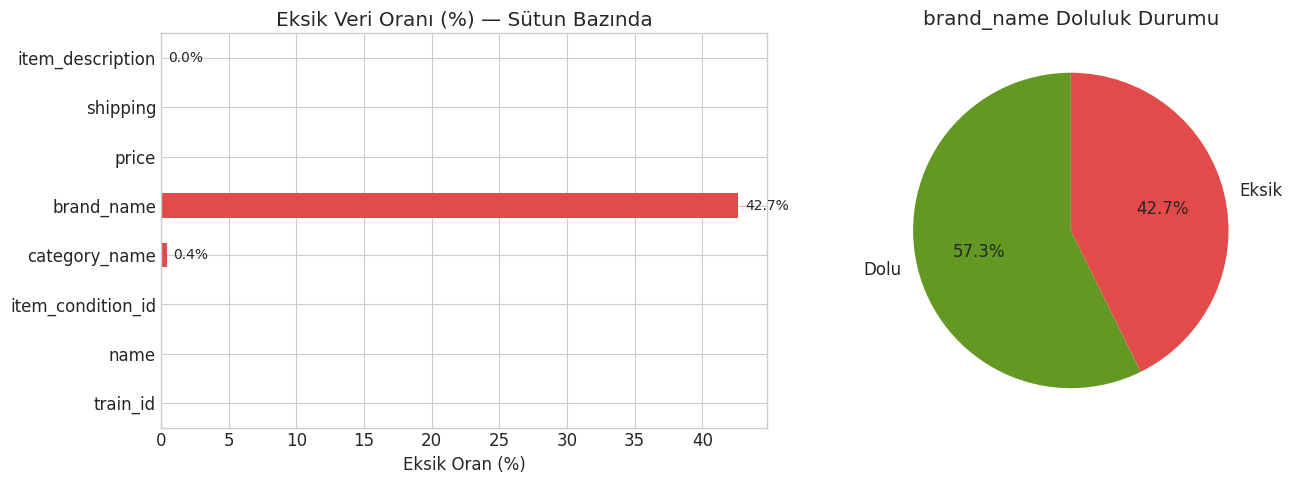

In [10]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Eksik veri oranları (tüm sütunlar)
missing_pct = (df.isnull().sum() / len(df) * 100)
colors = ['#E24B4A' if x > 0 else '#639922' for x in missing_pct]
missing_pct.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Eksik Veri Oranı (%) — Sütun Bazında')
axes[0].set_xlabel('Eksik Oran (%)')
for i, v in enumerate(missing_pct):
    if v > 0:
        axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)

# Sağ: brand_name doluluk pasta grafiği
brand_status = pd.Series({
    'Dolu': df['brand_name'].notna().sum(),
    'Eksik': df['brand_name'].isna().sum()
})
axes[1].pie(brand_status, labels=brand_status.index, autopct='%1.1f%%',
            colors=['#639922', '#E24B4A'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('brand_name Doluluk Durumu')

plt.tight_layout()
plt.savefig('data/processed/01_missing_data.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Hedef Değişken: Price

Fiyat dağılımı sağa çarpık (right-skewed) olduğu için `log1p` dönüşümü uygulamamız gerekecek.  
Yarışma metriği **RMSLE** olduğundan, `log1p(price)` üzerinde RMSE optimize etmek = doğrudan RMSLE optimize etmek.

In [11]:
# Fiyat istatistikleri
print("=== Fiyat İstatistikleri ===")
print(f"Min:      ${df['price'].min():.2f}")
print(f"Max:      ${df['price'].max():.2f}")
print(f"Ortalama: ${df['price'].mean():.2f}")
print(f"Medyan:   ${df['price'].median():.2f}")
print(f"Std:      ${df['price'].std():.2f}")
print(f"Çarpıklık (Skewness): {df['price'].skew():.2f}")
print(f"Basıklık (Kurtosis):  {df['price'].kurtosis():.2f}")


=== Fiyat İstatistikleri ===
Min:      $0.00
Max:      $2009.00
Ortalama: $26.74
Medyan:   $17.00
Std:      $38.59
Çarpıklık (Skewness): 11.39
Basıklık (Kurtosis):  283.82


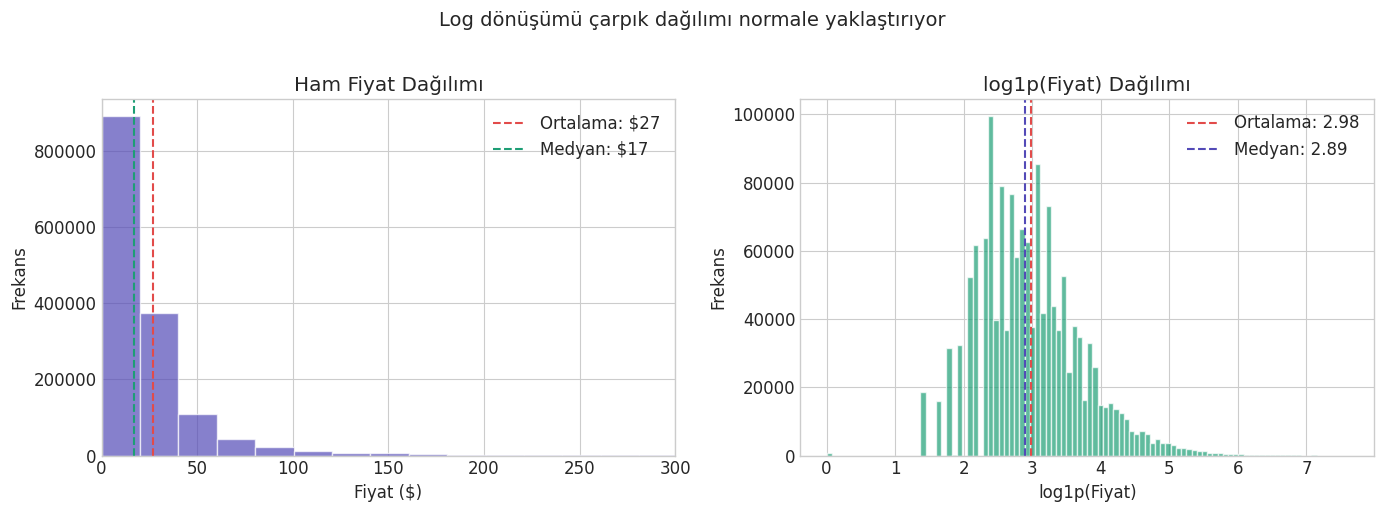


Dönüşüm sonrası çarpıklık: 0.66 (öncesi: 11.39)


In [12]:
# Fiyat dağılımı: Ham vs Log dönüşümü
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Ham fiyat dağılımı
axes[0].hist(df['price'], bins=100, color='#534AB7', alpha=0.7, edgecolor='white')
axes[0].set_title('Ham Fiyat Dağılımı')
axes[0].set_xlabel('Fiyat ($)')
axes[0].set_ylabel('Frekans')
axes[0].axvline(df['price'].mean(), color='#E24B4A', linestyle='--', label=f'Ortalama: ${df["price"].mean():.0f}')
axes[0].axvline(df['price'].median(), color='#1D9E75', linestyle='--', label=f'Medyan: ${df["price"].median():.0f}')
axes[0].legend()
axes[0].set_xlim(0, 300)  # Outlier'ları kesmeden görselleştir

# Sağ: Log1p dönüşümü
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=100, color='#1D9E75', alpha=0.7, edgecolor='white')
axes[1].set_title('log1p(Fiyat) Dağılımı')
axes[1].set_xlabel('log1p(Fiyat)')
axes[1].set_ylabel('Frekans')
axes[1].axvline(log_price.mean(), color='#E24B4A', linestyle='--', label=f'Ortalama: {log_price.mean():.2f}')
axes[1].axvline(log_price.median(), color='#534AB7', linestyle='--', label=f'Medyan: {log_price.median():.2f}')
axes[1].legend()

plt.suptitle('Log dönüşümü çarpık dağılımı normale yaklaştırıyor', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/processed/02_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDönüşüm sonrası çarpıklık: {log_price.skew():.2f} (öncesi: {df['price'].skew():.2f})")


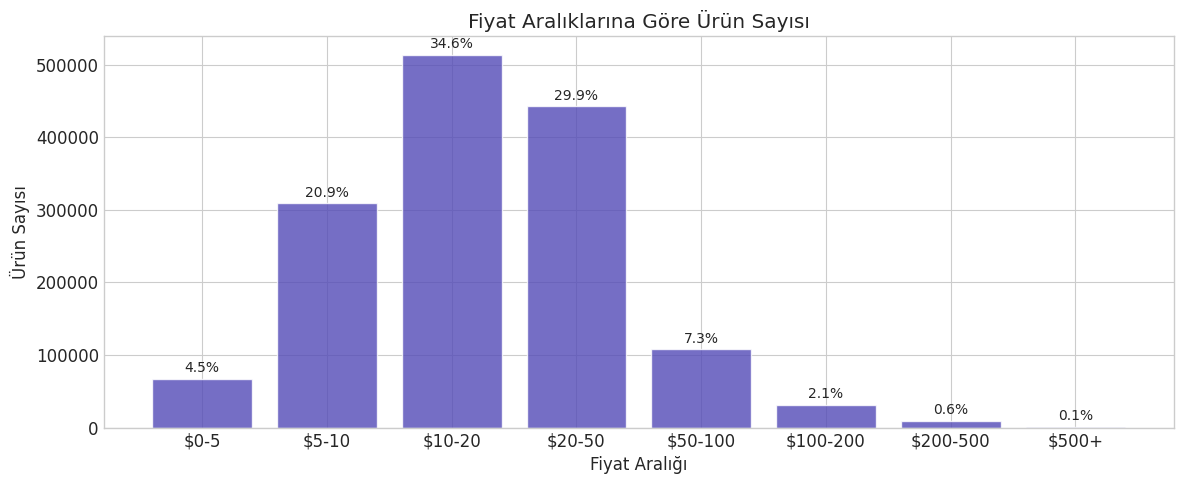

In [13]:
# Fiyat aralıkları analizi
bins = [0, 5, 10, 20, 50, 100, 200, 500, 2100]
labels = ['$0-5', '$5-10', '$10-20', '$20-50', '$50-100', '$100-200', '$200-500', '$500+']
df['price_bin'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(12, 5))
price_counts = df['price_bin'].value_counts().sort_index()
bars = ax.bar(range(len(price_counts)), price_counts.values, color='#534AB7', alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(price_counts)))
ax.set_xticklabels(price_counts.index, rotation=0)
ax.set_title('Fiyat Aralıklarına Göre Ürün Sayısı')
ax.set_xlabel('Fiyat Aralığı')
ax.set_ylabel('Ürün Sayısı')

# Yüzdeleri bar üstüne yaz
for bar, count in zip(bars, price_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('data/processed/03_price_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop('price_bin', axis=1, inplace=True)


## 4. Kategorik Değişkenler

### 4.1 Kategori Hiyerarşisi
`category_name` sütunu `"Ana/Alt1/Alt2"` formatında 3 seviyeli hiyerarşi içeriyor.

In [14]:
# Kategori hiyerarşisini parçala
def split_category(cat):
    if pd.isna(cat):
        return ['missing', 'missing', 'missing']
    parts = cat.split('/')
    while len(parts) < 3:
        parts.append('missing')
    return parts[:3]

cat_split = df['category_name'].apply(split_category)
df['cat_main'] = cat_split.apply(lambda x: x[0])
df['cat_sub1'] = cat_split.apply(lambda x: x[1])
df['cat_sub2'] = cat_split.apply(lambda x: x[2])

print(f"Ana kategoriler (cat_main): {df['cat_main'].nunique()}")
print(f"Alt kategoriler 1 (cat_sub1): {df['cat_sub1'].nunique()}")
print(f"Alt kategoriler 2 (cat_sub2): {df['cat_sub2'].nunique()}")
print(f"Benzersiz tam kategori yolu: {df['category_name'].nunique()}")


Ana kategoriler (cat_main): 11
Alt kategoriler 1 (cat_sub1): 114
Alt kategoriler 2 (cat_sub2): 871
Benzersiz tam kategori yolu: 1287


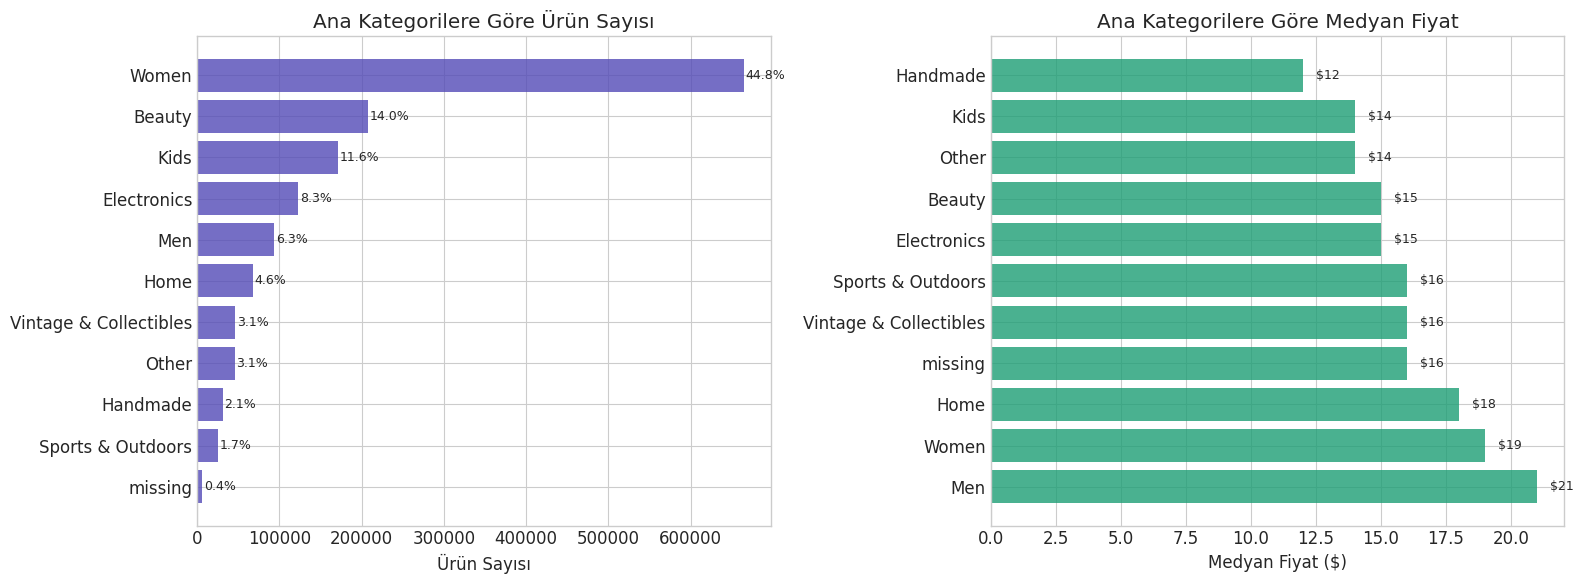

In [15]:
# Ana kategori dağılımı ve medyan fiyatları
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol: Ana kategori dağılımı
cat_counts = df['cat_main'].value_counts()
bars = axes[0].barh(range(len(cat_counts)), cat_counts.values, color='#534AB7', alpha=0.8)
axes[0].set_yticks(range(len(cat_counts)))
axes[0].set_yticklabels(cat_counts.index)
axes[0].set_title('Ana Kategorilere Göre Ürün Sayısı')
axes[0].set_xlabel('Ürün Sayısı')
axes[0].invert_yaxis()

for bar, count in zip(bars, cat_counts.values):
    pct = count / len(df) * 100
    axes[0].text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%', va='center', fontsize=9)

# Sağ: Kategoriye göre medyan fiyat
cat_price = df.groupby('cat_main')['price'].median().sort_values(ascending=True)
axes[1].barh(range(len(cat_price)), cat_price.values, color='#1D9E75', alpha=0.8)
axes[1].set_yticks(range(len(cat_price)))
axes[1].set_yticklabels(cat_price.index)
axes[1].set_title('Ana Kategorilere Göre Medyan Fiyat')
axes[1].set_xlabel('Medyan Fiyat ($)')
axes[1].invert_yaxis()

for bar, val in zip(axes[1].patches, cat_price.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'${val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/processed/04_categories.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Item Condition & Shipping

Shipping dağılımı:
  Alıcı öder (0): 819,435 (55.3%)
  Satıcı öder (1): 663,100 (44.7%)


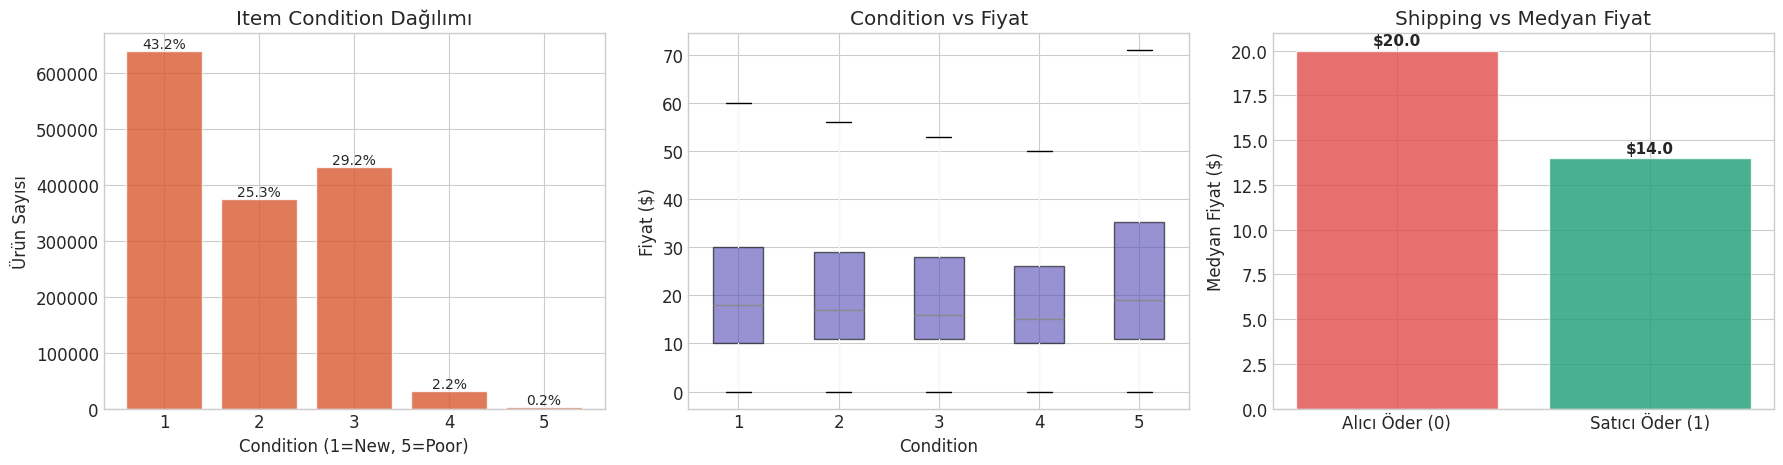

In [16]:
# Condition ve Shipping analizi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Condition dağılımı
cond_counts = df['item_condition_id'].value_counts().sort_index()
axes[0].bar(cond_counts.index, cond_counts.values, color='#D85A30', alpha=0.8, edgecolor='white')
axes[0].set_title('Item Condition Dağılımı')
axes[0].set_xlabel('Condition (1=New, 5=Poor)')
axes[0].set_ylabel('Ürün Sayısı')
for i, (idx, v) in enumerate(cond_counts.items()):
    axes[0].text(idx, v + 5000, f'{v/len(df)*100:.1f}%', ha='center', fontsize=10)

# Condition vs Price (boxplot)
df.boxplot(column='price', by='item_condition_id', ax=axes[1],
           showfliers=False, patch_artist=True,
           boxprops=dict(facecolor='#534AB7', alpha=0.6))
axes[1].set_title('Condition vs Fiyat')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Fiyat ($)')
axes[1].get_figure().suptitle('')

# Shipping vs Price
ship_price = df.groupby('shipping')['price'].agg(['mean', 'median'])
x = ['Alıcı Öder (0)', 'Satıcı Öder (1)']
axes[2].bar(x, ship_price['median'], color=['#E24B4A', '#1D9E75'], alpha=0.8, edgecolor='white')
axes[2].set_title('Shipping vs Medyan Fiyat')
axes[2].set_ylabel('Medyan Fiyat ($)')
for i, v in enumerate(ship_price['median']):
    axes[2].text(i, v + 0.3, f'${v:.1f}', ha='center', fontsize=11, fontweight='bold')

# Shipping dağılım bilgisi
ship_counts = df['shipping'].value_counts()
print(f"Shipping dağılımı:")
print(f"  Alıcı öder (0): {ship_counts[0]:,} ({ship_counts[0]/len(df)*100:.1f}%)")
print(f"  Satıcı öder (1): {ship_counts[1]:,} ({ship_counts[1]/len(df)*100:.1f}%)")

plt.tight_layout()
plt.savefig('data/processed/05_condition_shipping.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Marka (Brand) Analizi

Benzersiz marka sayısı: 4,809
Markası eksik olan ürünler: 632,682 (42.7%)



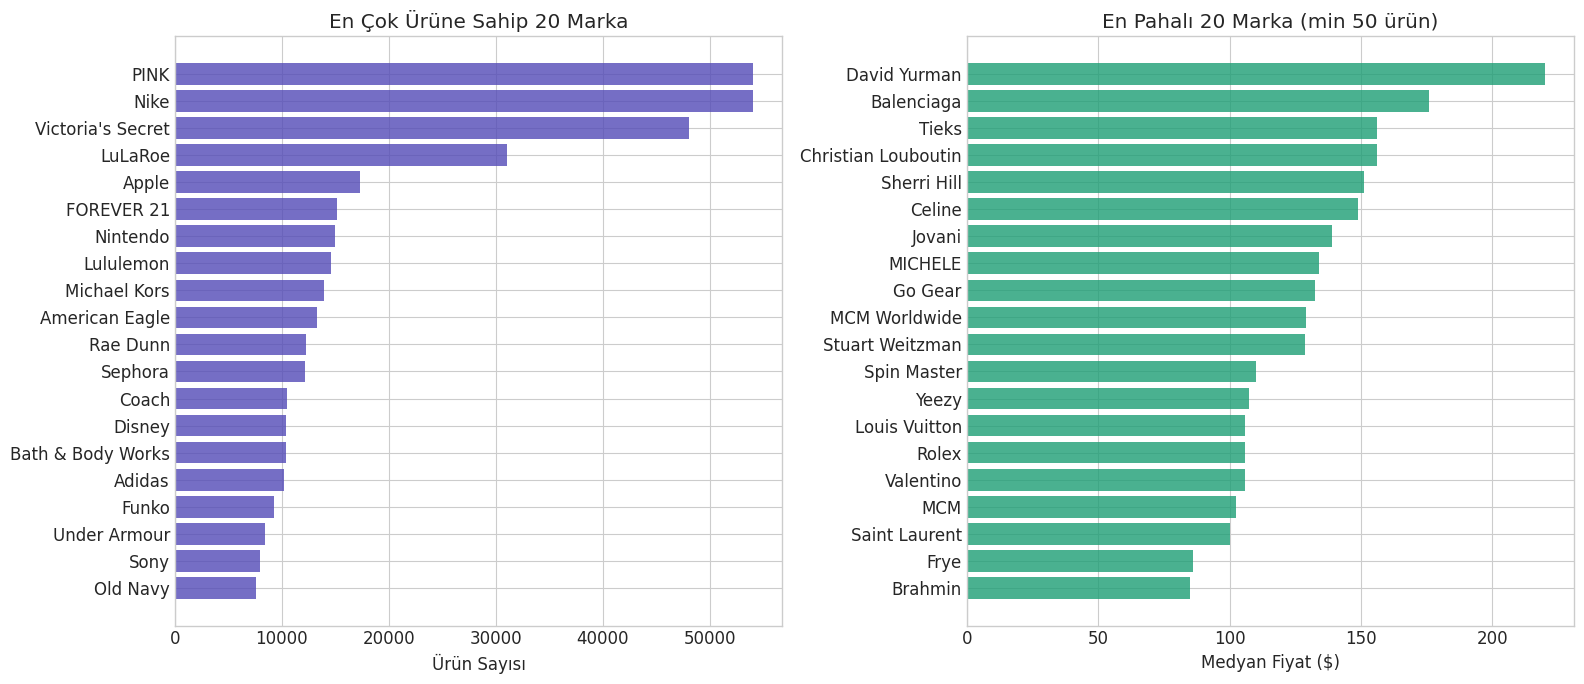

In [17]:
# Top 20 marka
print(f"Benzersiz marka sayısı: {df['brand_name'].nunique():,}")
print(f"Markası eksik olan ürünler: {df['brand_name'].isna().sum():,} ({df['brand_name'].isna().mean()*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 20 en çok ürüne sahip marka
top_brands = df['brand_name'].value_counts().head(20)
axes[0].barh(range(len(top_brands)), top_brands.values, color='#534AB7', alpha=0.8)
axes[0].set_yticks(range(len(top_brands)))
axes[0].set_yticklabels(top_brands.index)
axes[0].set_title('En Çok Ürüne Sahip 20 Marka')
axes[0].set_xlabel('Ürün Sayısı')
axes[0].invert_yaxis()

# Top 20 en pahalı marka (min 50 ürün)
brand_price = df.groupby('brand_name').agg(
    median_price=('price', 'median'),
    count=('price', 'count')
).query('count >= 50').sort_values('median_price', ascending=False).head(20)

axes[1].barh(range(len(brand_price)), brand_price['median_price'].values, color='#1D9E75', alpha=0.8)
axes[1].set_yticks(range(len(brand_price)))
axes[1].set_yticklabels(brand_price.index)
axes[1].set_title('En Pahalı 20 Marka (min 50 ürün)')
axes[1].set_xlabel('Medyan Fiyat ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('data/processed/06_brands.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Metin Analizi

`name` ve `item_description` sütunlarındaki metin özelliklerini inceleyelim.

In [18]:
# Metin uzunlukları
df['name_len'] = df['name'].str.len()
df['desc_len'] = df['item_description'].fillna('').str.len()
df['desc_word_count'] = df['item_description'].fillna('').str.split().str.len()
df['has_description'] = (df['item_description'].fillna('No description yet') != 'No description yet').astype(int)

print("=== Name Uzunluğu ===")
print(f"  Ortalama: {df['name_len'].mean():.0f} karakter")
print(f"  Min/Max: {df['name_len'].min()}/{df['name_len'].max()}")
print()
print("=== Description Uzunluğu ===")
print(f"  Ortalama: {df['desc_len'].mean():.0f} karakter")
print(f"  Ortalama kelime: {df['desc_word_count'].mean():.0f}")
print(f"  Açıklaması olan: {df['has_description'].sum():,} ({df['has_description'].mean()*100:.1f}%)")


=== Name Uzunluğu ===
  Ortalama: 26 karakter
  Min/Max: 1/43

=== Description Uzunluğu ===
  Ortalama: 146 karakter
  Ortalama kelime: 26
  Açıklaması olan: 1,400,040 (94.4%)


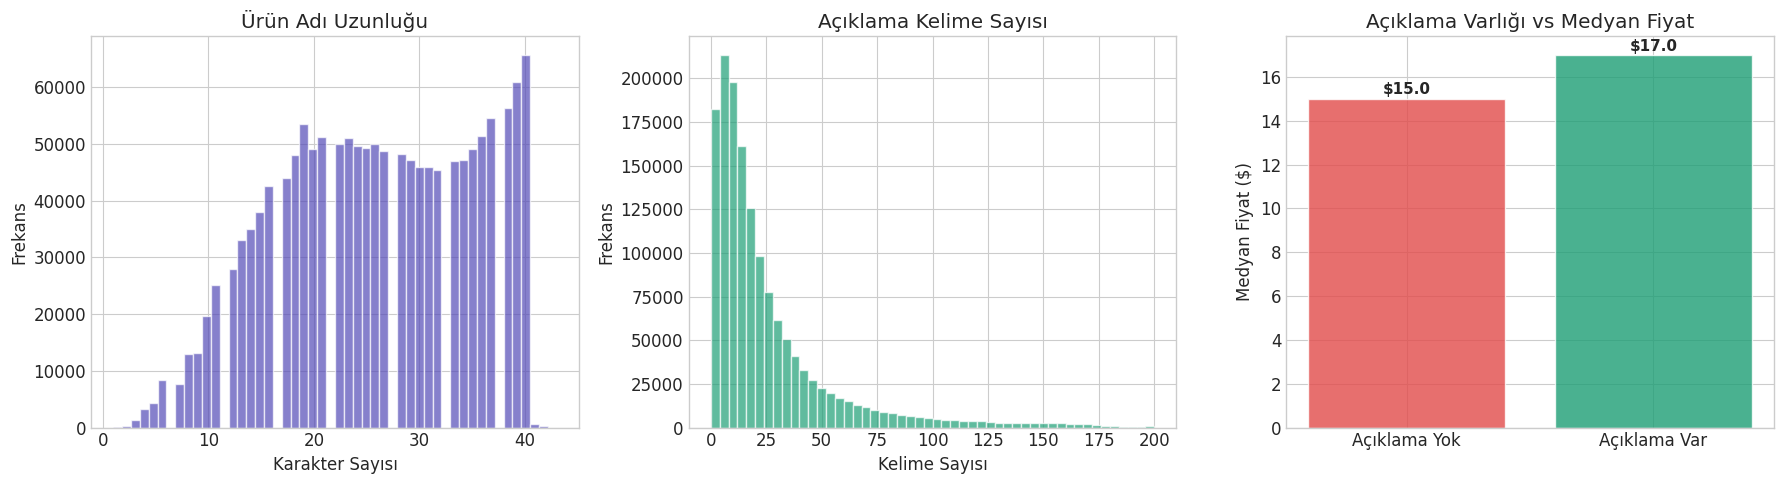

In [19]:
# Metin uzunlukları dağılımı
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Name uzunluğu
axes[0].hist(df['name_len'], bins=50, color='#534AB7', alpha=0.7, edgecolor='white')
axes[0].set_title('Ürün Adı Uzunluğu')
axes[0].set_xlabel('Karakter Sayısı')
axes[0].set_ylabel('Frekans')

# Description kelime sayısı
axes[1].hist(df['desc_word_count'].clip(upper=200), bins=50, color='#1D9E75', alpha=0.7, edgecolor='white')
axes[1].set_title('Açıklama Kelime Sayısı')
axes[1].set_xlabel('Kelime Sayısı')
axes[1].set_ylabel('Frekans')

# Açıklama varlığı vs fiyat
desc_price = df.groupby('has_description')['price'].median()
axes[2].bar(['Açıklama Yok', 'Açıklama Var'], desc_price.values,
            color=['#E24B4A', '#1D9E75'], alpha=0.8, edgecolor='white')
axes[2].set_title('Açıklama Varlığı vs Medyan Fiyat')
axes[2].set_ylabel('Medyan Fiyat ($)')
for i, v in enumerate(desc_price.values):
    axes[2].text(i, v + 0.2, f'${v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('data/processed/07_text_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Değişkenler Arası İlişkiler

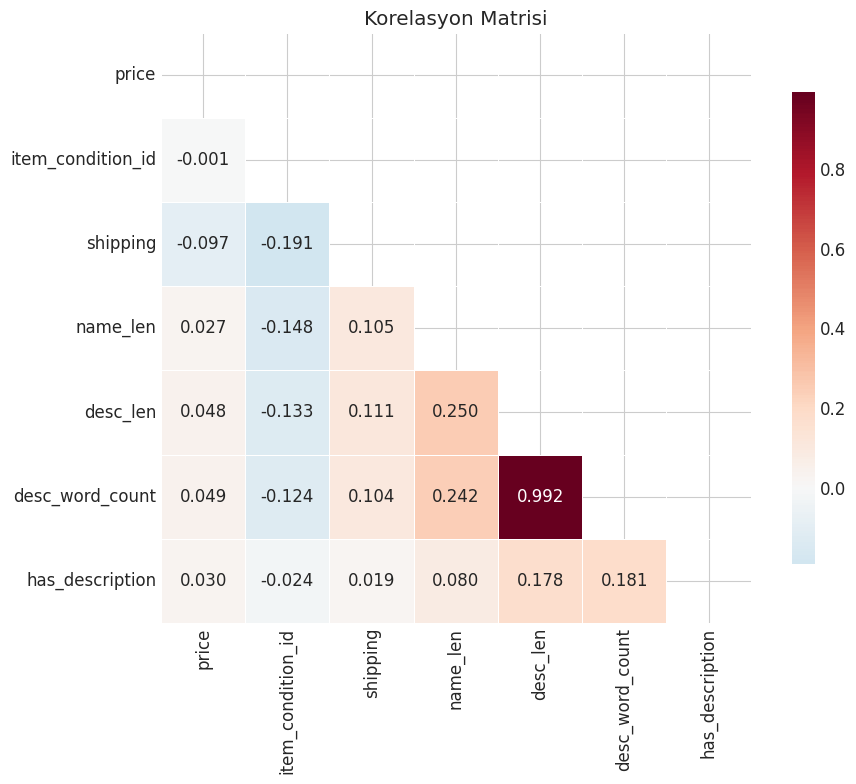

In [20]:
# Sayısal değişkenler arası korelasyon
numeric_cols = ['price', 'item_condition_id', 'shipping', 'name_len', 'desc_len', 'desc_word_count', 'has_description']

fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title('Korelasyon Matrisi')

plt.tight_layout()
plt.savefig('data/processed/08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


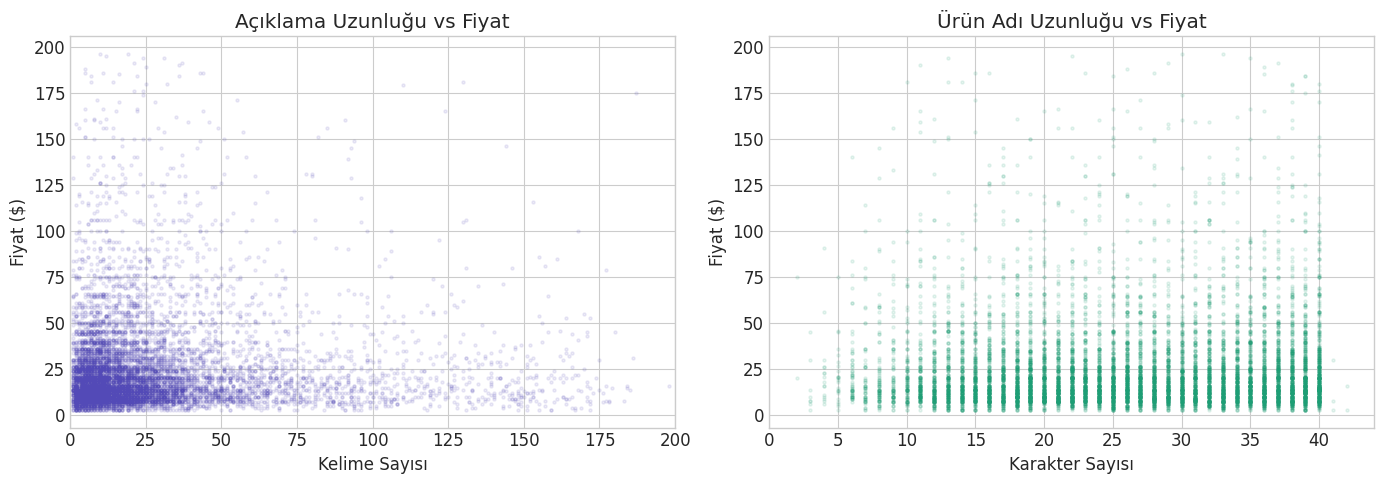

In [21]:
# Açıklama uzunluğu vs fiyat (scatter)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sadece açıklaması olan ve fiyatı < 200 olan ürünleri görselleştir
mask = (df['has_description'] == 1) & (df['price'] > 0) & (df['price'] < 200)
sample = df[mask].sample(10000, random_state=42)

axes[0].scatter(sample['desc_word_count'], sample['price'], alpha=0.1, s=5, color='#534AB7')
axes[0].set_title('Açıklama Uzunluğu vs Fiyat')
axes[0].set_xlabel('Kelime Sayısı')
axes[0].set_ylabel('Fiyat ($)')
axes[0].set_xlim(0, 200)

axes[1].scatter(sample['name_len'], sample['price'], alpha=0.1, s=5, color='#1D9E75')
axes[1].set_title('Ürün Adı Uzunluğu vs Fiyat')
axes[1].set_xlabel('Karakter Sayısı')
axes[1].set_ylabel('Fiyat ($)')

plt.tight_layout()
plt.savefig('data/processed/09_text_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. EDA Sonuçları ve Feature Engineering Önerileri

### Temel Bulgular:
1. **Fiyat dağılımı sağa çarpık** → `log1p(price)` dönüşümü zorunlu
2. **brand_name %43 eksik** → "missing" olarak dolduracağız, top-N brand encoding yapacağız
3. **category_name 3 seviyeli** → `/` ile split edip 3 ayrı feature oluşturacağız
4. **item_condition pek ayırt edici değil** → yine de feature olarak kalacak
5. **shipping fiyatı etkiliyor** → alıcı öderse fiyat daha yüksek
6. **Metin uzunluğu fiyatla zayıf korelasyon** → TF-IDF ile kelime bazlı bilgi çıkaracağız

### Adım 3 (Feature Engineering) için plan:
- `category_name` → `cat_main`, `cat_sub1`, `cat_sub2` (LabelEncoder)
- `brand_name` → Top-500 marka LabelEncoder, geri kalanı "other"
- `name` → TF-IDF vectorizer (max 50K feature, unigram+bigram)
- `item_description` → TF-IDF vectorizer (max 50K feature)
- `item_condition_id`, `shipping` → olduğu gibi
- `desc_word_count`, `name_len` → ek sayısal feature'lar
- Tüm sparse matrisler `scipy.sparse.hstack` ile birleştirilecek


In [22]:
# Eklenen geçici sütunları temizle
temp_cols = ['cat_main', 'cat_sub1', 'cat_sub2', 'name_len', 'desc_len', 'desc_word_count', 'has_description']
df.drop(columns=temp_cols, inplace=True)

print("EDA tamamlandı!")
print("Sonraki adım: 'Adım 3: Feature engineering yap' de")


EDA tamamlandı!
Sonraki adım: 'Adım 3: Feature engineering yap' de
